|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>FFNs<h1>|
|<h2>Lecture:</h2>|<h1><b>FFN to classify digits<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

from torchvision import datasets

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Setup GPU

# Import and process the data

In [2]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


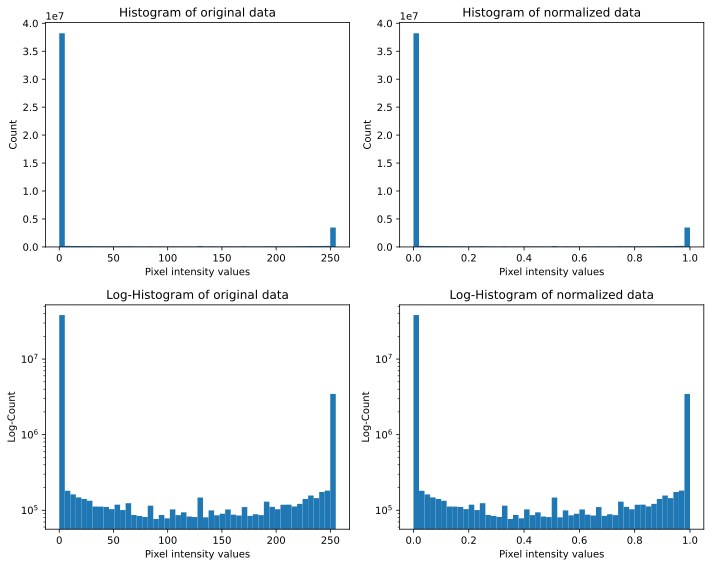

In [3]:
# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)

fig,ax = plt.subplots(2,2,figsize=(10,8))
ax[0,0].hist(data.flatten(),50)
ax[0,0].set_xlabel('Pixel intensity values')
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Histogram of original data')

ax[1,0].hist(data.flatten(),50)
ax[1,0].set_xlabel('Pixel intensity values')
ax[1,0].set_ylabel('Log-Count')
ax[1,0].set_yscale('log')
ax[1,0].set_title('Log-Histogram of original data')

ax[0,1].hist(dataNorm.flatten(),50)
ax[0,1].set_xlabel('Pixel intensity values')
ax[0,1].set_ylabel('Count')
ax[0,1].set_title('Histogram of normalized data')

ax[1,1].hist(dataNorm.flatten(),50)
ax[1,1].set_xlabel('Pixel intensity values')
ax[1,1].set_ylabel('Log-Count')
ax[1,1].set_yscale('log')
ax[1,1].set_title('Log-Histogram of normalized data')

fig.tight_layout()
plt.show()

# Create train/test groups using DataLoader

In [4]:
# Step 1: convert to tensor
dataT   = torch.tensor( dataNorm).float()
labelsT = torch.tensor( labels).long() # long = int64

# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)

# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [5]:
# check all variables in workspace
%whos

Variable            Type             Data/Info
----------------------------------------------
DataLoader          type             <class 'torch.utils.data.dataloader.DataLoader'>
F                   module           <module 'torch.nn.functio<...>/torch/nn/functional.py'>
TensorDataset       type             <class 'torch.utils.data.dataset.TensorDataset'>
ax                  ndarray          2x2: 4 elems, type `object`, 32 bytes
batchsize           int              32
data                ndarray          60000x784: 47040000 elems, type `uint8`, 47040000 bytes (44.86083984375 Mb)
dataNorm            ndarray          60000x784: 47040000 elems, type `float64`, 376320000 bytes (358.88671875 Mb)
dataT               Tensor           tensor([[0., 0., 0.,  ...<...>, 0.,  ..., 0., 0., 0.]])
datasets            module           <module 'torchvision.data<...>on/datasets/__init__.py'>
fig                 Figure           Figure(1000x800)
labels              ndarray          60000: 60000 elems, ty

# Create the DL model

In [6]:
# create a class for the model
def createTheMNISTNet():

  class mnistNet(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return torch.log_softmax( self.output(x),axis=1 )
      # NEW HERE: log-softmax the output, because I'm using NLLLoss instead of CrossEntropyLoss

  # create the model instance
  net = mnistNet()

  # loss function
  lossfun = nn.NLLLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.01)

  return net,lossfun,optimizer

In [7]:
# test the model with one batch
net,lossfun,optimizer = createTheMNISTNet()

X,y = next(iter(train_loader))
yHat = net(X)

# values are log-probability of each number (0-9)
# print(torch.exp(yHat))

# now let's compute the loss
loss = lossfun(yHat,y)
print(' ')
print('Loss:')
print(loss)

 
Loss:
tensor(2.3066, grad_fn=<NllLossBackward0>)


# Create a function that trains the model

In [8]:
# a function that trains the model

def function2trainTheModel():

  # number of epochs
  numepochs = 40

  # create a new model
  net,lossfun,optimizer = createTheMNISTNet()

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []

  # loop over epochs
  for epochi in range(numepochs):
    
    net.train()  # set the model to training mode

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( torch.mean(torch.tensor(batchAcc) ) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    net.eval()  # set the model to evaluation mode
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad():  # no need to track gradients
      yHat = net(X)
      # compare the following really long line of code to the training accuracy lines
      testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )

  # end epochs

  # function output
  return trainAcc,testAcc,losses,net


# Run the model and show the results!

In [9]:
trainAcc,testAcc,losses,net = function2trainTheModel()

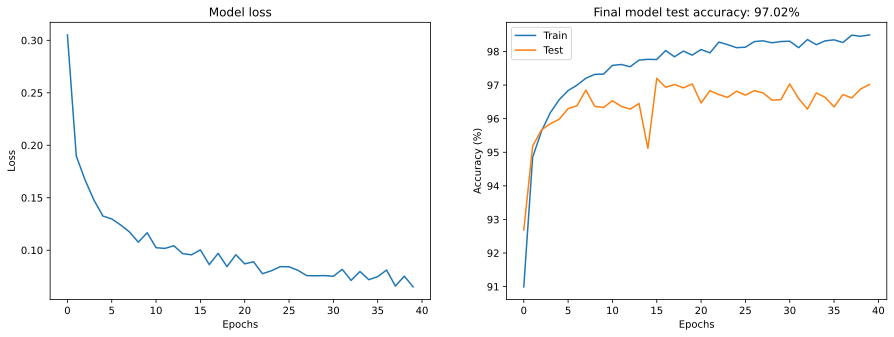

In [10]:
fig,ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
# ax[0].set_ylim([0,0.5])
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,label='Train')
ax[1].plot(testAcc,label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
# ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()

# Inspect the results in more detail

In [11]:
# run the model through for the test data
X,y = next(iter(test_loader))
predictions = net(X).detach()

predictions

tensor([[-1.8002e+02, -4.8766e+01, -3.8762e+01,  ..., -6.8993e+01,
         -6.3832e+01, -3.7576e+01],
        [-1.8797e+01, -1.4389e+01, -2.2591e+01,  ..., -3.9171e+01,
         -5.9605e-07, -2.1443e+01],
        [-4.3983e+01,  0.0000e+00, -3.3668e+01,  ..., -3.7082e+01,
         -2.6696e+01, -3.3974e+01],
        ...,
        [-4.9384e+00, -3.7402e+00, -3.9600e+00,  ..., -1.8827e-01,
         -7.7735e+00, -3.0878e+00],
        [-1.2838e+01, -6.4383e+00, -7.2566e+00,  ..., -1.5289e+01,
         -1.9024e+01, -6.3573e+00],
        [-2.6325e+01, -1.2405e+01, -1.4368e+01,  ..., -3.1261e+01,
         -4.0498e+01, -1.3054e+01]])

/tmp/ipykernel_1141/1990962932.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.bar(range(10),np.exp(predictions[sample2show])) # try adding exp!


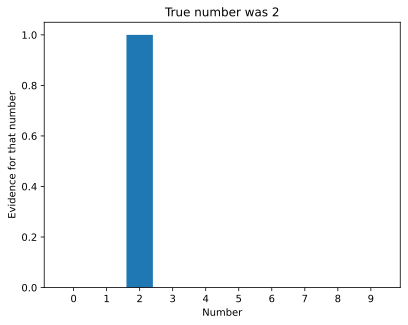

In [12]:
# Evidence for all numbers from one sample
sample2show = 10

plt.bar(range(10),np.exp(predictions[sample2show])) # try adding exp!
plt.xticks(range(10))
plt.xlabel('Number')
plt.ylabel('Evidence for that number')
plt.title('True number was %s' %y[sample2show].item())
plt.show()

[  43   99  129  157  264  281  294  299  352  371  390  409  415  432
  476  492  507  521  570  580  639  646  649  673  688  694  725  737
  799  801  805  816  844  872  880  920  956  958  960 1038 1042 1062
 1097 1160 1221 1236 1307 1380 1391 1404 1524 1549 1580 1591 1597 1643
 1676 1800 1810 1822 1850 1879 1882 1888 1897 1961 1965 1975 1984 2017
 2158 2179 2192 2215 2239 2391 2453 2489 2547 2572 2588 2599 2783 2830
 2863 2927 3014 3070 3127 3132 3154 3158 3246 3264 3291 3321 3330 3385
 3393 3561 3562 3579 3586 3616 3707 3714 3735 3756 3810 3814 3845 3896
 3919 3943 3975 4010 4035 4071 4072 4135 4137 4152 4157 4180 4190 4238
 4394 4416 4446 4452 4453 4482 4550 4573 4586 4621 4640 4643 4679 4726
 4761 4764 4773 4804 4818 4824 4842 4872 4881 4884 4889 4912 4929 4934
 4954 5019 5036 5056 5074 5103 5190 5209 5239 5264 5315 5431 5468 5493
 5547 5579 5600 5647 5689 5754 5782 5805 5829 5856 5888]


/tmp/ipykernel_1141/1915953787.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[0].bar(range(10),np.exp(predictions[errors[sample2show]]))


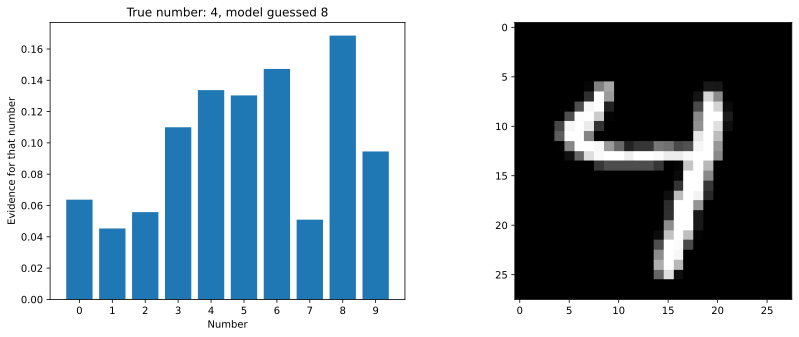

In [25]:
# find the errors
errors = np.where( torch.max(predictions,axis=1)[1] != y )[0]
print(errors)

# Evidence for all numbers from one sample
sample2show = 10

fig,ax = plt.subplots(1,2,figsize=(14,5))

ax[0].bar(range(10),np.exp(predictions[errors[sample2show]]))
ax[0].set_xticks(range(10))
ax[0].set_xlabel('Number')
ax[0].set_ylabel('Evidence for that number')
ax[0].set_title('True number: %s, model guessed %s'
                %( y[errors[sample2show]].item(), torch.argmax(predictions[errors[sample2show]]).item() ))

ax[1].imshow( np.reshape(X[errors[sample2show],:],(28,28)) ,cmap='gray')

plt.show()

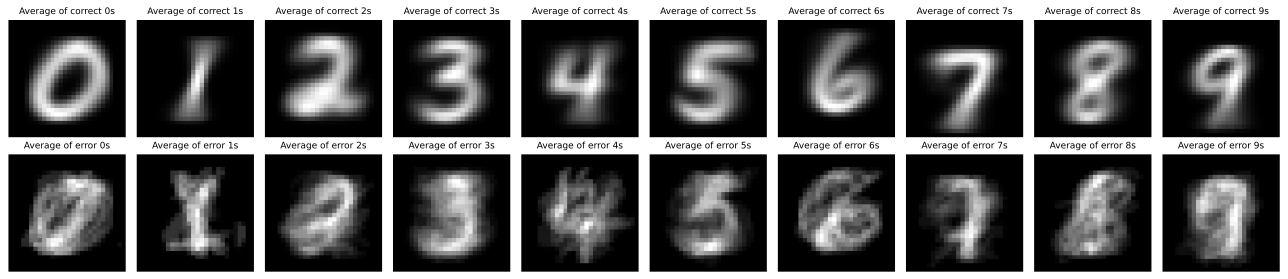

In [97]:
# 1) Average together the correct 7's and the error 7's, and make images of them (that is, one image
#    of all correct 7's and one image of all incorrectly labeled 7's). How do they look?
# Answer: The averaged correct 7's are more concentrated around typical shape of true 7, while the averaged wrong 7's are more diffused and less defined.
# 2) Repeat #1 for all numbers to produce a 2x10 matrix of images with corrects on top
#    and errors on the bottom.

# Run the model:
X,y = next(iter(test_loader))
predictions = net(X).detach()

correctPredictionsIdxs = np.argwhere(torch.max(predictions,axis=1)[1] == y)[0]
correctPredictedData = X[correctPredictionsIdxs,:]
correctPredictedLabels = y[correctPredictionsIdxs]

wrongPredictionsIdxs = np.argwhere(torch.max(predictions,axis=1)[1] != y)[0]
wrongPredictedData = X[wrongPredictionsIdxs,:]
wrongPredictedLabels = y[wrongPredictionsIdxs]

fig,axs = plt.subplots(2,10,figsize=(18,4))
imDim = (28,28)
for i in range(10):
    correctIdxs = np.argwhere(correctPredictedLabels == i)[0]
    errorIdxs = np.argwhere(wrongPredictedLabels == i)[0]

    avgCorrectNums = np.reshape(torch.mean(correctPredictedData[correctIdxs], axis=0), imDim)
    avgErrorNums = np.reshape(torch.mean(wrongPredictedData[errorIdxs], axis=0), imDim)

    axs[0,i].imshow(avgCorrectNums,cmap='gray')
    axs[0,i].title.set_text(f'Average of correct {i}s')
    axs[0,i].axis('off')
    axs[1,i].imshow(avgErrorNums,cmap='gray')
    axs[1,i].title.set_text(f'Average of error {i}s')
    axs[1,i].axis('off')

for ax in axs.flat:
    ax.title.set_fontsize(9)
fig.tight_layout()
plt.show()


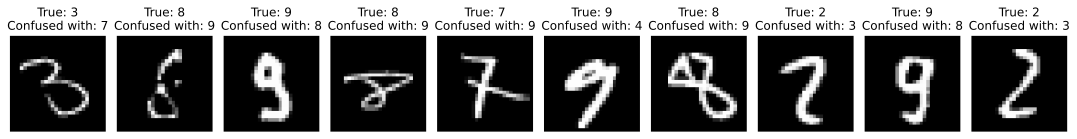

In [ ]:
# 3) Identify "almost errors," which we can define as correct categorizations that had a probability of
#    e.g., >.1 for any other number. Make images of some of these numbers. Can you understand why the model
#    was confused?
# Answer: In my opinion the almost errors are occuring due to insufficient hidden layer design.

# Identify "almost errors"
almost_errors = []
almost_errors_labels = []
correctPredictionsIdxs = np.argwhere(torch.max(predictions,axis=1)[1] == y)[0]
otherNumProbabilityThreshold = .1
predictionsProbabilities = torch.exp(predictions)  # convert log-probabilities to probabilities
for idx in correctPredictionsIdxs:
    probs = predictionsProbabilities[idx]
    correct_label = y[idx].item()
    idxThreshold = [i for i in range(10) if probs[i] > otherNumProbabilityThreshold and i != correct_label]
    if len(idxThreshold) > 0:
        almost_errors.append(idx)
        almost_errors_labels.append(np.max(idxThreshold))

# Visualize some "almost errors"
num_to_show = 10
fig, axs = plt.subplots(1, num_to_show, figsize=(15, 5))
for i, idx in enumerate(almost_errors[:num_to_show]):
    axs[i].imshow(X[idx].reshape(28, 28), cmap='gray')
    axs[i].set_title(f'True: {y[idx].item()}\nConfused with: {almost_errors_labels[i]}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# Additional explorations

In [16]:
# 1) Average together the correct 7's and the error 7's, and make images of them (that is, one image
#    of all correct 7's and one image of all incorrectly labeled 7's). How do they look?
#
# 2) Repeat #1 for all numbers to produce a 2x10 matrix of images with corrects on top
#    and errors on the bottom.
#
# 3) Identify "almost errors," which we can define as correct categorizations that had a probability of
#    e.g., >.1 for any other number. Make images of some of these numbers. Can you understand why the model
#    was confused?
#
# 4) I didn't use .train(), .eval(), or no_grad() here. Is that a problem? Can you add those in without checking
#    other notebooks?
# added
#